In [7]:
# MATH 0001. Social Network Advertising
# In this session, we will discover 4 algorithms for classification, and evaluate their performance

## first ,import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import toolkit components from scikit-learn pacakge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


## now we begin to implement the 4 methods via one core function engine
## once you insert the four ML function commands as an introductory exercise, you will see the visualization immediately.


In [9]:

# pacakge for 4 algorithms
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Step 1: Load advertising source dataset
dataset = pd.read_csv('Social_Network_Ads.csv')

# Step 2: Extract features (Age, EstimatedSalary) and target (Purchased)
X = dataset[['Age','EstimatedSalary']].values
Y = dataset['Purchased'].values

# Step 3: Stratified Train/Test Split (75% Training, 25% Testing)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size = 0.25,
    stratify =Y,
    random_state = 123
)

# Step 4: Continuous Feature Scaling via Standardization
# Ensures Gaussian modeling, SVM boundary margin calculation, and tree splits run optimally
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



In [14]:
# step 5.
# CORE STEP. Unified training, evaluation & visualization pipeline
def run_classification_pipeline(model_name:str, classifier_instance):
  """
  Fits the given classifier, reports performance, and plots the decision boundary
  """
  # Step 6. Model training & prediction vector generation
  classifier = classifier_instance
  classifier.fit(X_train,Y_train)
  Y_pred = classifier.predict(X_test)

  # Step 7. Performance Measurement via Confusion Matrix
  cm = confusion_matrix(Y_test,Y_pred)

  print("=" * 80)
  print(f"  PERFORMANCE SUMMARY REPORT FOR: {model_name.upper()}")
  print("=" * 80)
  print(f"  Confusion Matrix (Test Set Validation):\n{cm}")
  print(f"  Overall Accuracy Score: {((cm[0,0] + cm[1,1]) / len(Y_test)):.4f}")
  print("=" * 80)

  # Step 8. Complete 2D Decision Boundary Visualization Pipeline

  # Set up meshgrid dimensions tracking scaled predictor boundaries
  x1_min, x1_max  = X_train[:,0].min()-1, X_train[:,0].max()+1
  x2_min, x2_max  = X_train[:,1].min()-1, X_train[:,1].max()+1

  X1, X2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                         np.arange(x2_min, x2_max, 0.02))

  # Run coordinate grid predictions to build continuous background segments
  Z_grid = classifier.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape)

  ## visualization
  fig, axes = plt.subplots(1,2,figsize=(15,6))
  datasets_to_plot = [('Training Set',X_train, Y_train),('Test Set', X_test, Y_test)]

  for idx, (set_title, X_data, Y_data) in enumerate(datasets_to_plot):
    ax = axes[idx]
    # Draw background classification regions
    # alpha=0.3 establishes a light transparent background overlay
    ax.pcolormesh(X1,X2,Z_grid,cmap=plt.cm.RdYlGn, alpha=0.3, shading='auto', zorder=1)

    # Scatter plot observed target classes (0 = Tomato Red, 1 = Spring Green)
    # zorder=3 places real data coordinates layered on top of the background grid split
    sns.scatterplot(
        x=X_data[:, 0], y=X_data[:, 1], hue=Y_data, palette={0: 'tomato', 1: 'forestgreen'},
        s=60, edgecolor='black', linewidth=0.8, alpha=0.9, ax=ax, zorder=3
    )
    # Graphic canvas decoration configurations
    ax.set_title(f"{model_name} Classifier ({set_title})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Scaled Age", fontsize=10)
    ax.set_ylabel("Scaled Estimated Salary", fontsize=10)
    ax.set_xlim(X1.min(), X1.max())
    ax.set_ylim(X2.min(), X2.max())
    ax.grid(True, linestyle='--', alpha=0.4, zorder=2) # Light background grid alignment

    # Clean up the legend display labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No Purchase (0)', 'Purchased (1)'], loc='upper left', title="True Status")

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

  PERFORMANCE SUMMARY REPORT FOR: NAIVE BAYES
  Confusion Matrix (Test Set Validation):
[[62  2]
 [ 5 31]]
  Overall Accuracy Score: 0.9300
  PERFORMANCE SUMMARY REPORT FOR: DECISION TREE
  Confusion Matrix (Test Set Validation):
[[62  2]
 [ 7 29]]
  Overall Accuracy Score: 0.9100
  PERFORMANCE SUMMARY REPORT FOR: KERNEL SVM
  Confusion Matrix (Test Set Validation):
[[60  4]
 [ 4 32]]
  Overall Accuracy Score: 0.9200
  PERFORMANCE SUMMARY REPORT FOR: RANDOM FOREST
  Confusion Matrix (Test Set Validation):
[[60  4]
 [ 7 29]]
  Overall Accuracy Score: 0.8900


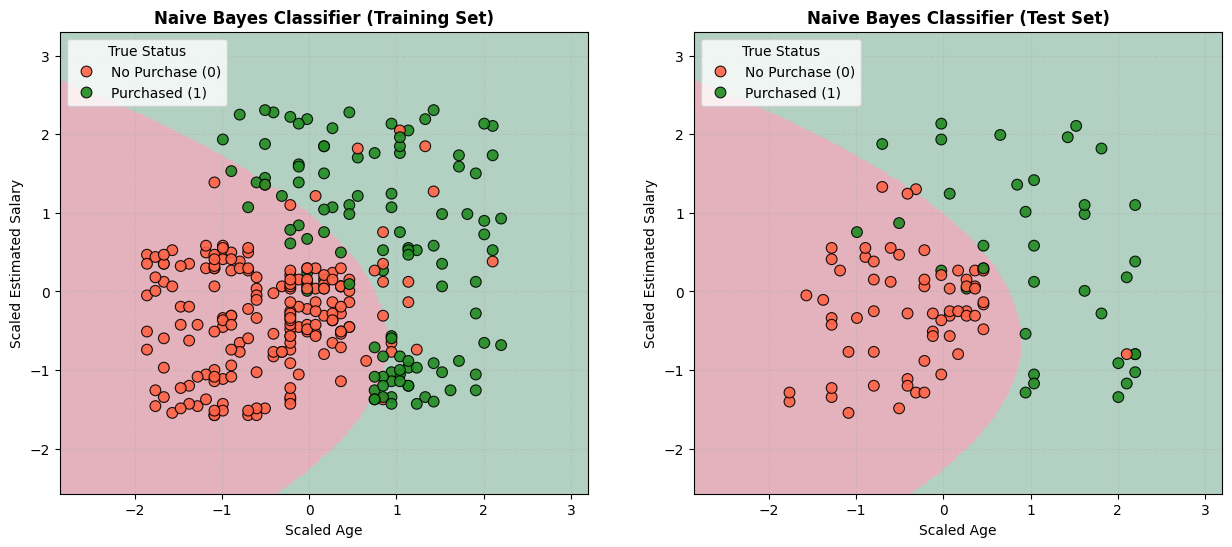

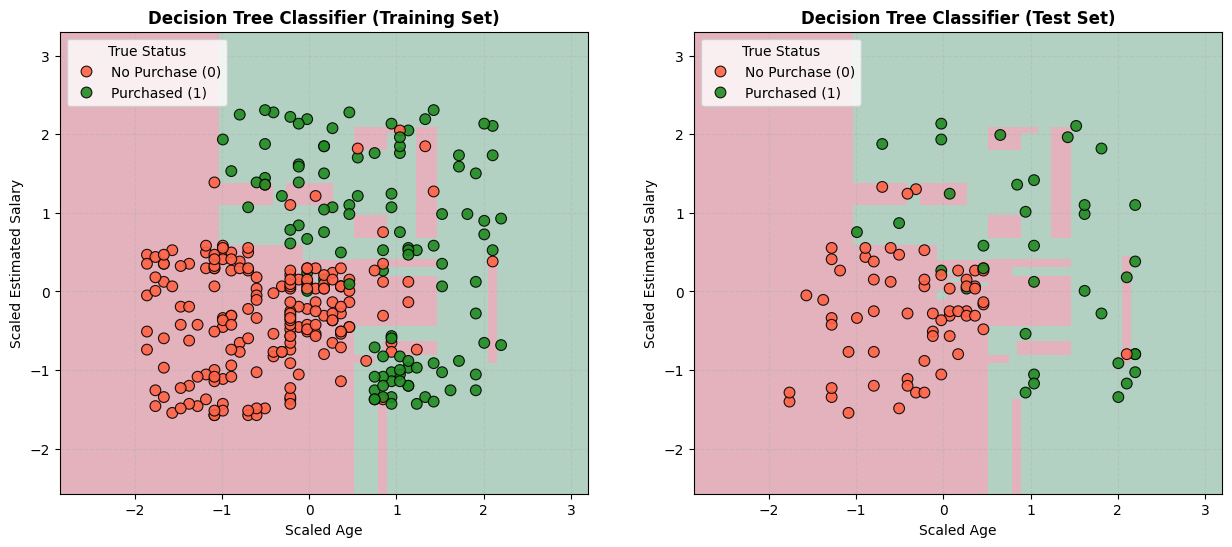

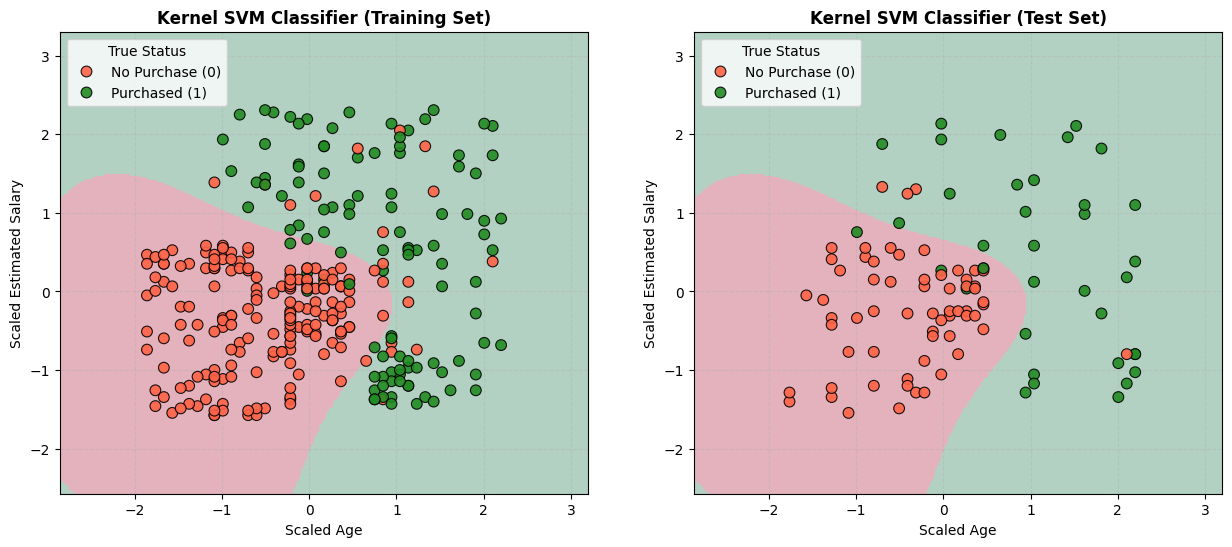

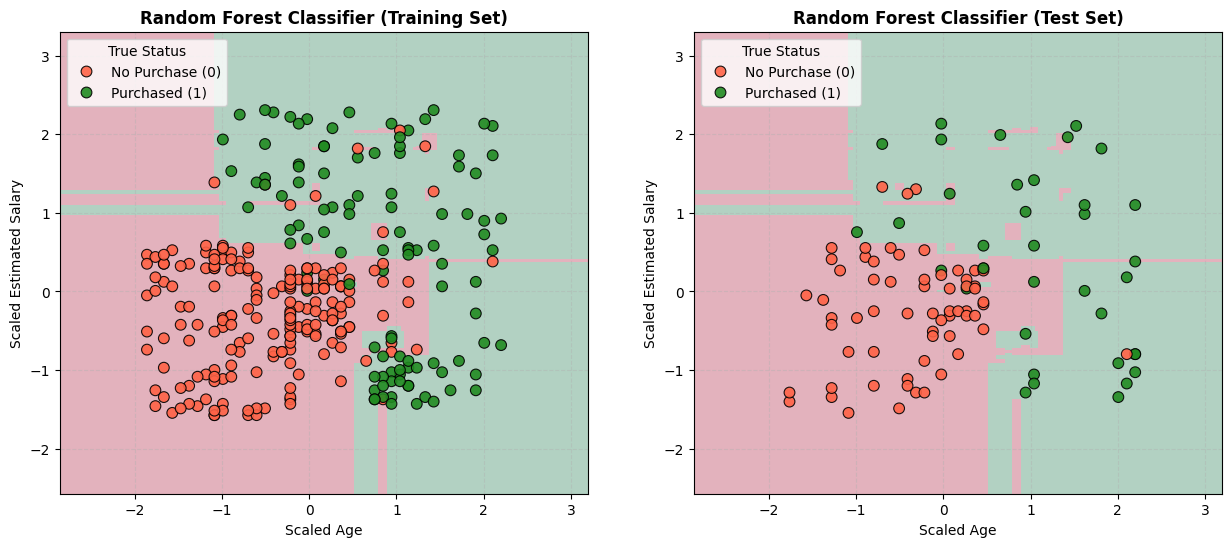

In [15]:
# EXECUTION CONTROLLER:

# 1. Naive Bayes Algorithm
run_classification_pipeline("Naive Bayes", GaussianNB())

# 2. Decision Tree Algorithm
run_classification_pipeline("Decision Tree", DecisionTreeClassifier(criterion='gini', random_state=123))

# 3. Kernal Support Vector Machine Algorithm
run_classification_pipeline("Kernel SVM", SVC(kernel='rbf', random_state=123))

# 4. Random Forest Algorithm
run_classification_pipeline("Random Forest", RandomForestClassifier(n_estimators=10, criterion='gini', random_state=123))